# Multicollinearity and Regression Assumptions

## Overview

Linear regression rests on four key assumptions. Violations range from benign (mild non-normality with large n) to serious (heteroscedasticity inflating Type I error, multicollinearity making coefficients uninterpretable).

**The four OLS assumptions:**

| Assumption | Violation name | Consequence |
|---|---|---|
| Linearity | Misspecification | Biased coefficients |
| Homoscedasticity | Heteroscedasticity | Incorrect SEs |
| Independence of errors | Autocorrelation | Incorrect SEs |
| Normality of errors | Non-normality | Minor at large n; affects small-n inference |

**Multicollinearity:** predictor variables are correlated with each other, making coefficients unstable and hard to interpret. Detected via Variance Inflation Factor (VIF).

---

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan, het_white
from statsmodels.stats.stattools import durbin_watson
from scipy import stats

rng = np.random.default_rng(42)
n = 200
elevation   = rng.uniform(50, 400, n)
nitrate     = rng.gamma(2, 2, n)
# Deliberately correlated predictors
phosphorus  = 0.85*nitrate + rng.normal(0, 0.5, n)  # VIF problem
temperature = 15 - 0.02*elevation + rng.normal(0, 0.5, n)  # corr with elevation
treatment   = rng.choice([0,1], n)
richness    = (25 - 0.04*elevation - 0.8*nitrate + 2.5*treatment
               + rng.normal(0, 3.5, n))
df = pd.DataFrame(dict(richness=richness, elevation=elevation, nitrate=nitrate,
    phosphorus=phosphorus, temperature=temperature, treatment=treatment))
print(f"Correlation matrix (potential multicollinearity issues):")
print(df[['elevation','nitrate','phosphorus','temperature']].corr().round(2))

Correlation matrix (potential multicollinearity issues):
             elevation  nitrate  phosphorus  temperature
elevation         1.00     0.08        0.08        -0.97
nitrate           0.08     1.00        0.98        -0.05
phosphorus        0.08     0.98        1.00        -0.05
temperature      -0.97    -0.05       -0.05         1.00


---
## Variance Inflation Factor (VIF)

In [2]:
# VIF: how much variance of a coefficient is inflated by collinearity
model_full = smf.ols(
    'richness ~ elevation + nitrate + phosphorus + temperature + C(treatment)',
    data=df).fit()
X_vif = sm.add_constant(df[['elevation','nitrate','phosphorus','temperature']])
vif_df = pd.DataFrame({
    'feature': X_vif.columns,
    'VIF':     [variance_inflation_factor(X_vif.values, i)
                for i in range(X_vif.shape[1])]
}).query("feature != 'const'")
print("VIF values:")
print(vif_df.round(2))
print("\nVIF interpretation:")
print("  VIF < 5:  acceptable")
print("  VIF 5-10: moderate concern")
print("  VIF > 10: serious multicollinearity -- consider removing or combining predictors")
# Demonstrate instability: coefficients change dramatically with correlated predictors
m_nitr  = smf.ols('richness ~ nitrate', df).fit()
m_both  = smf.ols('richness ~ nitrate + phosphorus', df).fit()
print(f"\nNitrate coefficient alone:             {m_nitr.params['nitrate']:.3f}")
print(f"Nitrate coefficient with phosphorus:   {m_both.params['nitrate']:.3f}")
print("Large shift = multicollinearity inflating coefficient instability")

VIF values:
       feature    VIF
1    elevation  16.30
2      nitrate  26.53
3   phosphorus  26.56
4  temperature  16.25

VIF interpretation:
  VIF < 5:  acceptable
  VIF 5-10: moderate concern
  VIF > 10: serious multicollinearity -- consider removing or combining predictors

Nitrate coefficient alone:             -0.911
Nitrate coefficient with phosphorus:   -0.267
Large shift = multicollinearity inflating coefficient instability


---
## Heteroscedasticity

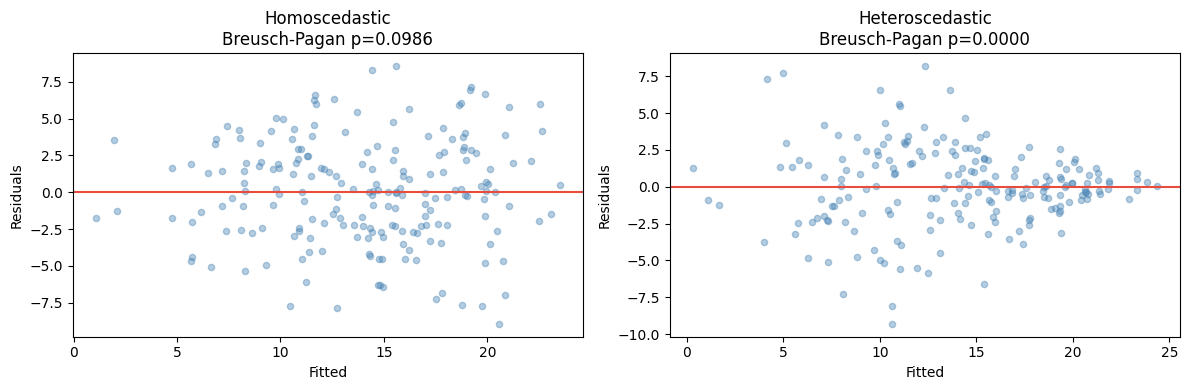

In [3]:
# Well-specified model: check for heteroscedasticity
model = smf.ols('richness ~ elevation + nitrate + C(treatment)', df).fit()
resid  = model.resid
fitted = model.fittedvalues

# Introduce heteroscedasticity deliberately
richness_het = (25 - 0.04*elevation - 0.8*nitrate + 2.5*treatment
                + rng.normal(0, 0.01*elevation, n))
model_het = smf.ols('richness_het ~ elevation + nitrate + C(treatment)',
                    df.assign(richness_het=richness_het)).fit()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, mod, title in [(axes[0], model, 'Homoscedastic'),
                        (axes[1], model_het, 'Heteroscedastic')]:
    ax.scatter(mod.fittedvalues, mod.resid, alpha=0.4, s=20, color='steelblue')
    ax.axhline(0, color='#e74c3c', lw=1.5)
    bp_stat, bp_p, _, _ = het_breuschpagan(mod.resid, mod.model.exog)
    ax.set_title(f'{title}\nBreusch-Pagan p={bp_p:.4f}')
    ax.set_xlabel('Fitted'); ax.set_ylabel('Residuals')
plt.tight_layout(); plt.show()

---
## Robust Standard Errors

In [4]:
# When heteroscedasticity is present: use HC3 robust SEs
model_robust = smf.ols('richness ~ elevation + nitrate + C(treatment)',
                        data=df).fit(cov_type='HC3')
model_ols    = smf.ols('richness ~ elevation + nitrate + C(treatment)',
                        data=df).fit()
print("Comparison of standard errors: OLS vs HC3 robust")
comparison = pd.DataFrame({
    'coef':       model_ols.params,
    'SE (OLS)':   model_ols.bse,
    'SE (HC3)':   model_robust.bse,
    'SE ratio':   model_robust.bse / model_ols.bse
}).round(3)
print(comparison)
print("\nSE ratio > 1: OLS underestimated uncertainty for this coefficient")
print("SE ratio < 1: OLS overestimated uncertainty (unusual)")
print("\nHC3 is the most commonly recommended HC estimator for small-n")

Comparison of standard errors: OLS vs HC3 robust
                     coef  SE (OLS)  SE (HC3)  SE ratio
Intercept          24.390     0.774     0.867     1.120
C(treatment)[T.1]   1.955     0.507     0.520     1.026
elevation          -0.036     0.003     0.003     1.082
nitrate            -0.791     0.087     0.081     0.939

SE ratio > 1: OLS underestimated uncertainty for this coefficient
SE ratio < 1: OLS overestimated uncertainty (unusual)

HC3 is the most commonly recommended HC estimator for small-n


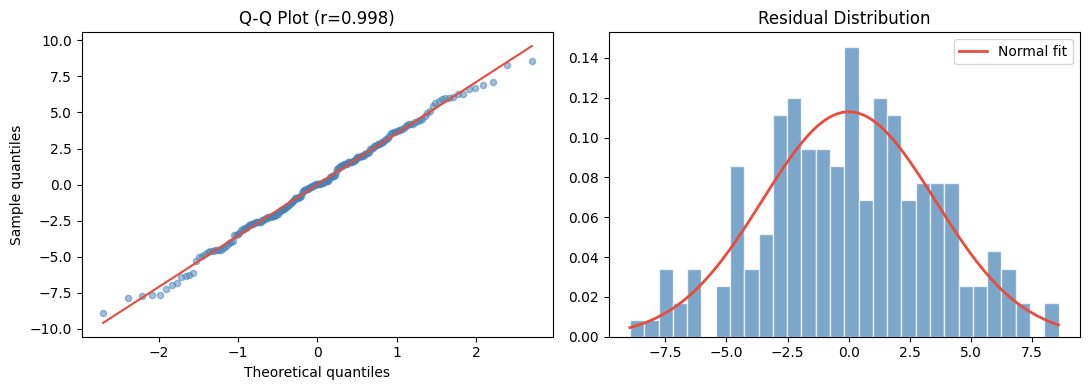

Shapiro-Wilk: W=0.9945, p=0.6823
Durbin-Watson: 1.6838  (2.0=no autocorrelation)


In [5]:
# Normality of residuals: Q-Q plot and Shapiro-Wilk
model = smf.ols('richness ~ elevation + nitrate + C(treatment)', df).fit()
resid = model.resid
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
# Q-Q plot
(osm, osr), (slope, intercept, r) = stats.probplot(resid, dist='norm')
axes[0].scatter(osm, osr, s=20, alpha=0.5, color='steelblue')
axes[0].plot(osm, slope*np.array(osm)+intercept, color='#e74c3c', lw=1.5)
axes[0].set_title(f'Q-Q Plot (r={r:.3f})')
axes[0].set_xlabel('Theoretical quantiles'); axes[0].set_ylabel('Sample quantiles')
# Residual histogram
axes[1].hist(resid, bins=30, density=True, color='steelblue', alpha=0.7, edgecolor='white')
xr = np.linspace(resid.min(), resid.max(), 100)
axes[1].plot(xr, stats.norm.pdf(xr, resid.mean(), resid.std()),
             color='#e74c3c', lw=2, label='Normal fit')
axes[1].set_title('Residual Distribution')
axes[1].legend(); plt.tight_layout(); plt.show()
sw_stat, sw_p = stats.shapiro(resid)
print(f"Shapiro-Wilk: W={sw_stat:.4f}, p={sw_p:.4f}")
dw = durbin_watson(resid)
print(f"Durbin-Watson: {dw:.4f}  (2.0=no autocorrelation)")

---

## Common Pitfalls

**1. Removing a correlated predictor without domain justification**  
VIF flags multicollinearity but does not indicate which predictor to remove. Removing nitrate because phosphorus is correlated with it may discard the scientifically relevant predictor. Always use domain knowledge to decide which correlated predictor to retain, combine, or remove.

**2. Applying heteroscedasticity tests to large samples and acting on any significant result**  
Breusch-Pagan detects trivial heteroscedasticity at large n. A p < 0.05 with n = 1000 may reflect unimportant variance differences. Examine the residual plot and the ratio of robust to OLS standard errors; only switch to robust SEs or WLS if the difference is practically meaningful.

**3. Using robust SEs as a universal fix without diagnosing the cause**  
Robust standard errors correct for heteroscedasticity but do not fix model misspecification. If residuals have a non-linear pattern (indicating a missing predictor or wrong functional form), robust SEs give correct inference for the wrong model. Diagnose first, then decide whether the fix is SEs or the model itself.

**4. Treating Durbin-Watson as irrelevant for cross-sectional data**  
The Durbin-Watson test is typically discussed for time series, but spatial autocorrelation in cross-sectional ecological data produces the same problem — errors at nearby sites are correlated, inflating effective sample size and deflating SEs. Always consider whether observations have a spatial or temporal ordering that could induce autocorrelation.

**5. Centring and scaling only some predictors before checking VIF**  
VIF for interaction terms and polynomial terms is artificially inflated when the constituent terms are not centred. Always mean-centre continuous predictors before creating interaction or polynomial terms, then recompute VIF.
---
*python_methods_library - Samantha McGarrigle*